# Decision Tree - Automobile Loan Default Prediction
Single interpretable tree baseline with `class_weight='balanced'` and `max_depth=6`.

## 1. Setup

In [1]:
import os
import sys

project_root = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from src.config import RANDOM_STATE, TARGET
from src.data.data_cleaning import clean_and_split
from src.evaluation.metrics import evaluate_model, results_to_row
from src.preprocessing.feature_engineering import build_pipeline

train_df, test_df = clean_and_split()
X_train, y_train = train_df.drop(columns=[TARGET]), train_df[TARGET]
X_test, y_test = test_df.drop(columns=[TARGET]), test_df[TARGET]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Default rate (train):", round(y_train.mean(), 4))
print("Default rate (test):", round(y_test.mean(), 4))

X_train shape: (95372, 40)
X_test shape: (23844, 40)
Default rate (train): 0.081
Default rate (test): 0.081


## 2. Decision Tree
Single interpretable tree baseline with `class_weight='balanced'` and `max_depth=6`.

In [3]:
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve
from src.evaluation.metrics import log_result_to_csv
from src.models.decision_tree import build_decision_tree_pipeline, evaluate_decision_tree, save_decision_tree_model


### 3.1 5-Fold Stratified Cross-Validation
Same protocol as every other model: the shared pipeline, `evaluate_model`, stratified 5-fold CV on the training split, threshold 0.5. The result is logged with `log_result_to_csv`, which keeps one row per model.


In [4]:
dt_cv_results = evaluate_model(build_decision_tree_pipeline(), X_train, y_train, model_name="decision_tree", cv=5)

for key, value in dt_cv_results.items():
    print(f"{key}: {value}")

results_dir = "../experiments/results" if os.path.exists("../experiments/results") else "experiments/results"
log_result_to_csv(dt_cv_results, os.path.join(results_dir, "experiments.csv"))


model_name: decision_tree
cv_folds: 5
threshold: 0.5
roc_auc_mean: 0.7081826318431956
roc_auc_std: 0.003783205094030031
pr_auc_mean: 0.1807175642717052
pr_auc_std: 0.004464595295450644
recall_mean: 0.60668217717189
precision_mean: 0.15185553323712758
f1_mean: 0.2422317714795962
confusion_matrix: [[61284, 26364], [3038, 4686]]
fit_seconds: 22.61


,model_name,cv_folds,threshold,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,recall_mean,precision_mean,f1_mean,fit_seconds,tn,fp,fn,tp
0,gaussian_naive_bayes,5,0.5,0.696815,0.003703,0.176248,0.008833,0.479027,0.169532,0.250394,17.15,69518,18130,4024,3700
1,XGBoost Baseline,5,0.5,0.763093,0.004383,0.261403,0.009897,0.022009,0.621743,0.042488,39.12,87542,106,7554,170
2,LightGBM Baseline,5,0.5,0.748190,0.003018,0.228391,0.008387,0.644226,0.167997,0.266493,22.52,63002,24646,2748,4976
3,random_forest,5,0.5,0.774053,0.003994,0.357554,0.009321,0.163386,0.632070,0.259549,99.39,86910,738,6462,1262
4,random_forest_tuned,5,0.5,0.769818,0.004141,0.338804,0.009196,0.284568,0.380683,0.325650,72.31,84073,3575,5526,2198
5,decision_tree,5,0.5,0.708183,0.003783,0.180718,0.004465,0.606682,0.151856,0.242232,22.61,61284,26364,3038,4686


### 3.2 Train Decision Tree
The full pipeline (preprocessing + tree with `max_depth=6`, `min_samples_leaf=20`, `class_weight='balanced'`) is fitted on the training split.


In [5]:
import time

dt_model = build_decision_tree_pipeline()
start = time.time()
dt_model.fit(X_train, y_train)
print(f"Trained in {time.time() - start:.2f} seconds.")


Trained in 5.51 seconds.


### 3.3 Model Evaluation (held-out test set, reference only)


In [6]:
metrics, cm = evaluate_decision_tree(dt_model, X_test, y_test)

# Show nicely formatted table
results_df = pd.DataFrame([metrics])
results_df


,accuracy,precision,recall,f1_score,roc_auc,pr_auc,tn,fp,fn,tp
0,0.7218,0.1627,0.5873,0.2548,0.7194,0.1857,16077,5836,797,1134


Held-out test set, reference only (not used for any decision):<br>
Recall: 58.73% → Correctly identifies 58.7% of actual defaulters.<br>
Accuracy: 72.18% → Lower than 91.9%, but accuracy is less useful with imbalanced data.<br>
Precision: 16.27% → Many flagged applicants are actually non-defaulters.<br>
ROC-AUC: 0.7194 → The model distinguishes defaulters from non-defaulters better than random.<br>
PR-AUC: 0.1857 → Higher than the 8.1% default rate, showing useful performance on the minority class.<br>


### 3.4 Confusion Matrix

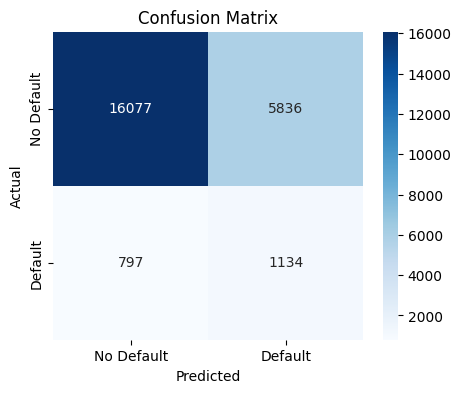

Correct Non-Defaults (TN): 16077 | Wrong Alarms (FP): 5836
Missed Defaults (FN):      797  | Caught Defaults (TP): 1134


In [7]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(f"Correct Non-Defaults (TN): {metrics['tn']} | Wrong Alarms (FP): {metrics['fp']}")
print(f"Missed Defaults (FN):      {metrics['fn']}  | Caught Defaults (TP): {metrics['tp']}")

### 3.5 ROC and Precision-Recall Curves

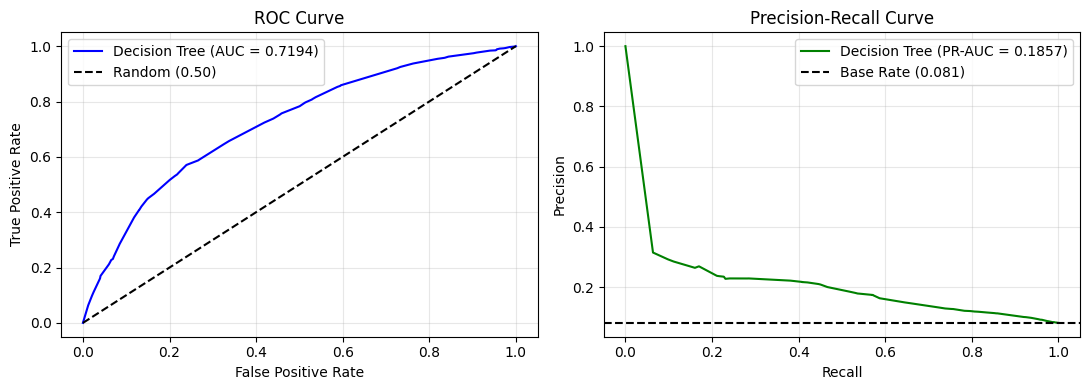

In [8]:
y_proba = dt_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ROC Curve
axes[0].plot(fpr, tpr, label=f"Decision Tree (AUC = {metrics['roc_auc']})", color="blue")
axes[0].plot([0, 1], [0, 1], "k--", label="Random (0.50)")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(recall_vals, precision_vals, label=f"Decision Tree (PR-AUC = {metrics['pr_auc']})", color="green")
axes[1].axhline(y=y_test.mean(), color="k", linestyle="--", label=f"Base Rate ({y_test.mean():.3f})")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
figures_dir = "experiments/figures" if os.path.exists("experiments/figures") else "../experiments/figures"
plt.savefig(os.path.join(figures_dir, "05_decision_tree_roc_pr.png"), dpi=100, bbox_inches="tight")
plt.show()


### 3.6 Save Model

In [9]:
models_dir = "../models/baseline" if os.path.exists("../models/baseline") else "models/baseline"
save_decision_tree_model(dt_model, os.path.join(models_dir, "decision_tree.pkl"))


Model saved to: ../models/baseline\decision_tree.pkl


'../models/baseline\\decision_tree.pkl'

### 3.7 Why These Settings Were Used

#### 1. Why `class_weight='balanced'`?
* In this dataset, **92%** of people pay their loan on time, and only **8%** default.
* If we do not use `balanced`, the tree will simply predict "No Default" for everyone. That gives a fake high accuracy of 92%, but catches **0 defaulters**.
* Setting `class_weight='balanced'` forces the tree to pay attention to defaulters, allowing it to catch **~60% of real defaulters**.

#### 2. Why `max_depth=6`?
* If a decision tree is allowed to grow with no limit, it grows 20+ levels deep and memorizes noise in the training data (overfitting).
* Capping the depth at **6** keeps the rules simple and prevents overfitting, so the model works well on new test data.


**Finding:** Decision Tree 5-fold stratified CV (shared pipeline, `evaluate_model`, threshold 0.5) gives ROC-AUC 0.708 ± 0.004, PR-AUC 0.181 ± 0.004, recall 0.607, precision 0.152, F1 0.242. Setting `class_weight='balanced'` lets the tree catch about 61% of actual defaulters, much more than Random Forest at the 0.5 threshold (0.163), but precision is low and there are many false alarms. Held-out test set, reference only: ROC-AUC 0.719, PR-AUC 0.186, recall 0.587, precision 0.163.

**Decision:** kept as the interpretable non-linear baseline, built with `build_decision_tree_pipeline()` in `src/models/decision_tree.py`. The fitted pipeline is saved to `models/baseline/decision_tree.pkl`.
